<a href="https://colab.research.google.com/github/mametaro99/fMRI-ALS-HC-classification/blob/main/FMRI_ReccurenceTriangle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os
import glob

def load_fmri_file(file_path, group_name):
    """
    Reads an fMRI data file, extracts the Subject ID from the filename,
    and adds SubjectID and Group columns.
    """
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Extract the base filename
    filename = os.path.basename(file_path)

    # Parse the Subject ID (assumes format like 'sub-HC5001_...')
    subject_id = filename.split('_')[0]

    # Assign new columns
    df['SubjectID'] = subject_id
    df['Group'] = group_name

    return df

In [2]:
import io
import pandas as pd

from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

# -----------------------------
# Drive API
# -----------------------------
drive_service = build("drive", "v3")

ALS_FOLDER_ID = "1dcGOujAwNrOhxtiw6-mV_UjrV1stxYbl"
HC_FOLDER_ID  = "16i40sw1HeyeU9-kc6leTsXxbzpYwyAKv"

FOLDER_MIME = "application/vnd.google-apps.folder"


# -----------------------------
# フォルダ直下のファイル一覧
# -----------------------------
def list_files_in_folder(folder_id):
    query = f"'{folder_id}' in parents and trashed = false"
    results = drive_service.files().list(
        q=query,
        fields="files(id, name, mimeType)",
        pageSize=1000
    ).execute()
    return results.get("files", [])


# -----------------------------
# 再帰的にCSVだけ集める
# -----------------------------
def collect_csv_files_recursive(folder_id):
    collected = []
    items = list_files_in_folder(folder_id)

    for item in items:
        if item["mimeType"] == FOLDER_MIME:
            # サブフォルダなら再帰
            collected.extend(collect_csv_files_recursive(item["id"]))
        elif item["name"].lower().endswith(".csv"):
            collected.append(item)

    return collected


# -----------------------------
# file_id から CSV を DataFrame として読む
# -----------------------------
def read_csv_from_drive(file_id):
    request = drive_service.files().get_media(fileId=file_id)
    buffer = io.BytesIO()
    downloader = MediaIoBaseDownload(buffer, request)

    done = False
    while not done:
        _, done = downloader.next_chunk()

    buffer.seek(0)
    return pd.read_csv(buffer)


# -----------------------------
# 1ファイル分の読み込み
# 必要に応じて列名整形など追加
# -----------------------------
def load_fmri_file(file_info, label):
    df = read_csv_from_drive(file_info["id"]).copy()
    df["group"] = label
    df["source_file"] = file_info["name"]
    return df


# -----------------------------
# CSV収集
# -----------------------------
als_files = collect_csv_files_recursive(ALS_FOLDER_ID)
hc_files  = collect_csv_files_recursive(HC_FOLDER_ID)

print("ALS csv files:", len(als_files))
for f in als_files[:5]:
    print("  ", f["name"], f["id"])

print("HC csv files:", len(hc_files))
for f in hc_files[:5]:
    print("  ", f["name"], f["id"])


# -----------------------------
# DataFrame結合
# -----------------------------
data_frames = []

for file_info in als_files:
    df = load_fmri_file(file_info, "ALS")
    data_frames.append(df)

for file_info in hc_files:
    df = load_fmri_file(file_info, "HC")
    data_frames.append(df)

fmri_data = pd.concat(data_frames, ignore_index=True)

print("Shape of combined DataFrame:", fmri_data.shape)
display(fmri_data.head())

ALS csv files: 24
   sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1Nu6o1jrK1KL8RSuN0kV-WhZibuIbEEkZ
   sub-ALS033_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1FyLtJ1j-zqICGJWMk6krDorKs0d0NJQv
   sub-ALS032_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 17jskalR83f_Y4hJKilId90W5Bl3oHTgA
   sub-ALS031_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1rex0n5g13PIfw8Ltk5hhG1Ggxe4WwDPW
   sub-ALS030_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1o-FUytixHfqZBhHi3W-TgQB7r-1XtHgr
HC csv files: 24
   sub-HC6007_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 11BZOw2GYqa_doyqNIwGY1jYfyE_Or1LN
   sub-HC7006_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1rIjMcWXupkSI4hkirdd3vVtNbkGP1jcb
   sub-HC7007_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S

,LH_Vis_1_Fusiform_L,LH_Vis_2_Fusiform_L,LH_Vis_3_Lingual_L,LH_Vis_4_Occipital_Mid_L,LH_Vis_5_Calcarine_L,LH_Vis_6_Calcarine_L,LH_Vis_7_Temporal_Mid_L,LH_Vis_8_Occipital_Mid_L,LH_Vis_9_Cuneus_L,LH_SomMot_1_Temporal_Sup_L,...,Cerebellar_Region3_LeftHemisphere,Cerebellar_Region4_LeftHemisphere,Cerebellar_Region5_LeftHemisphere,Cerebellar_Region6_RightHemisphere,Cerebellar_Region7_LeftHemisphere,Cerebellar_Region8_RightHemisphere,Cerebellar_Region9_RightHemisphere,Cerebellar_Region10_LeftHemisphere,group,source_file
0,0.659899,0.474176,1.113970,0.383730,0.731779,0.791733,0.030415,0.407028,0.748130,-0.987001,...,-0.391977,-0.359210,0.107012,-0.013251,-0.123381,0.956467,0.432258,0.367473,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
1,0.135694,0.960673,-0.345874,1.934692,1.570930,1.039831,-0.184959,-0.667202,-0.287384,0.414777,...,-0.429717,-0.367912,0.421250,-0.235084,1.272944,1.384500,0.385935,0.467817,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
2,-0.233580,3.053868,-0.254062,3.834575,3.919217,2.235851,0.380700,0.260332,0.043457,1.800574,...,0.221141,0.482651,0.999281,0.289586,2.123519,1.142630,0.648714,0.380323,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
3,-0.136169,4.618473,0.322399,4.257414,5.024313,2.351772,1.110155,2.002550,0.812399,2.317119,...,1.632144,2.035630,1.705305,1.364686,1.885215,0.393927,0.815867,0.336012,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
4,0.118256,4.132984,-0.228453,2.901738,3.453336,0.455231,1.330036,2.780549,0.886701,2.133701,...,3.248963,2.842216,2.402359,2.391043,1.411407,0.269060,0.835317,0.441388,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...


In [3]:
!pip install optuna

import numpy as np
import pandas as pd
import optuna
import scipy
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Group the fmri_data by SubjectID to process each subject individually
grouped = fmri_data.groupby('group')

# Initialize lists to store sequences and labels
X_seq = []
y = []

# Iterate over each subject group
for subject_id, group_df in grouped:
    # Extract the group label (it is constant for each subject)
    # We take the first value as they are all the same for the subject
    label = group_df['group'].iloc[0]
    y.append(label)

    # Drop metadata columns to keep only the numeric feature data
    # Convert the remaining DataFrame to a NumPy array
    subject_data = group_df.drop(columns=['group']).values
    X_seq.append(subject_data)

# Convert the labels list to a NumPy array
y = np.array(y)

# Verify the structure
print(f"Total number of subjects: {len(X_seq)}")
if len(X_seq) > 0:
    print(f"Shape of first subject's data: {X_seq[0].shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.4 MB/s eta 0:00:00
Total number of subjects: 2
Shape of first subject's data: (5523, 157)


In [4]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.8 MB/s eta 0:00:00


In [5]:

## すべての患者のデータに対して、すべての信号の組み合わせによるクロスリカレンスプロットを構築する　(157×156 /2 = 12246個ほどのリカレンスプロットを構築する)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from skopt import BayesSearchCV
from skopt.space import Real, Categorical


# =========================================================
# 0) fmri_data から患者ごとの時系列行列を作る
# =========================================================

def get_signal_columns(df):
    exclude_cols = {"group", "source_file"}
    # "index" 列は時系列の添字として入っているので除外
    signal_cols = [c for c in df.columns if c not in exclude_cols and c != "index"]
    return signal_cols


def build_subject_matrices(fmri_data):
    """
    Returns
    -------
    subject_ids : list[str]
    X_subjects  : list[np.ndarray]  # 各要素 shape = [T, n_channels]
    y           : np.ndarray        # ALS=1, HC=0
    signal_cols : list[str]
    """
    signal_cols = get_signal_columns(fmri_data)

    subject_ids = []
    X_subjects = []
    y = []

    for subject_id, g in fmri_data.groupby("group"):
        g = g.copy()

        # index 列があれば時系列順に並べる
        if "index" in g.columns:
            g = g.sort_values("index")
        else:
            g = g.reset_index(drop=True)

        group_name = g["group"].iloc[0]
        x = g[signal_cols].to_numpy(dtype=np.float32)

        # NaN/inf 対策
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        subject_ids.append(subject_id)
        X_subjects.append(x)
        y.append(1 if group_name == "ALS" else 0)

    return subject_ids, X_subjects, np.asarray(y, dtype=np.int64), signal_cols


# =========================================================
# 1) クロスリカレンスプロット
# =========================================================

def cross_recurrence_plot_1d(x, y, percentage=0.1):
    """
    x, y: shape [T]
    percentage: 上位何%を recurrence とみなすか（例 0.1 -> 10%）
    Returns
    -------
    R : np.ndarray, shape [T, T], dtype uint8
    """
    x = np.asarray(x, dtype=np.float32).ravel()
    y = np.asarray(y, dtype=np.float32).ravel()

    # |x_i - y_j|
    D = np.abs(x[:, None] - y[None, :])

    # 閾値
    thr = np.percentile(D, percentage * 100.0)

    R = (D < thr).astype(np.uint8)
    return R


# =========================================================
# 2) 再帰三角形 L=4 の頻度分布
#    上三角 6 bit -> 64パターン
# =========================================================

def extract_triangle_histogram_from_rp(rp, L=4, normalize=False):
    """
    rp : binary matrix [T, T]
    L  : triangle size

    Returns
    -------
    hist : np.ndarray shape [2^(L*(L-1)/2)]
    """
    rp = np.asarray(rp, dtype=np.uint8)
    n = rp.shape[0]
    if n < L:
        dim = 2 ** (L * (L - 1) // 2)
        return np.zeros(dim, dtype=np.float64)

    # [n-L+1, n-L+1, L, L]
    windows = sliding_window_view(rp, (L, L))
    # shape: (n-L+1, n-L+1, L, L)

    tri_i, tri_j = np.triu_indices(L, k=1)  # 上三角（対角除く）
    bits = windows[..., tri_i, tri_j]       # shape: [m, m, n_bits]

    n_bits = bits.shape[-1]
    weights = (1 << np.arange(n_bits, dtype=np.int64))  # [1,2,4,8,...]
    codes = np.tensordot(bits, weights, axes=([-1], [0])).ravel()

    dim = 2 ** n_bits
    hist = np.bincount(codes, minlength=dim).astype(np.float64)

    if normalize and hist.sum() > 0:
        hist /= hist.sum()

    return hist


# =========================================================
# 3) 1患者分の特徴量作成
#    すべてのチャネルペアの CRP -> 三角形頻度を合算
# =========================================================

def subject_feature_from_all_pairs(X_subject, L=4, percentage=0.1, normalize_each_pair=False):
    """
    X_subject : shape [T, C]
    Returns
    -------
    feat : shape [64] (L=4 の場合)
    """
    T, C = X_subject.shape
    n_patterns = 2 ** (L * (L - 1) // 2)

    total_hist = np.zeros(n_patterns, dtype=np.float64)

    for i, j in combinations(range(C), 2):
        rp = cross_recurrence_plot_1d(X_subject[:, i], X_subject[:, j], percentage=percentage)
        hist = extract_triangle_histogram_from_rp(rp, L=L, normalize=normalize_each_pair)
        total_hist += hist

    # 患者単位で正規化
    if total_hist.sum() > 0:
        total_hist /= total_hist.sum()

    return total_hist


def _subject_feature_worker(args):
    x_subject, L, percentage, normalize_each_pair = args
    return subject_feature_from_all_pairs(
        x_subject,
        L=L,
        percentage=percentage,
        normalize_each_pair=normalize_each_pair
    )


def build_feature_matrix(
    X_subjects,
    L=4,
    percentage=0.1,
    normalize_each_pair=False,
    n_jobs=1
):
    """
    Returns
    -------
    X_feat : shape [n_subjects, 64]
    """
    args_list = [(x, L, percentage, normalize_each_pair) for x in X_subjects]

    if n_jobs == 1:
        feats = [_subject_feature_worker(a) for a in args_list]
    else:
        with ProcessPoolExecutor(max_workers=n_jobs) as ex:
            feats = list(ex.map(_subject_feature_worker, args_list))

    return np.vstack(feats)


# =========================================================
# 4) 可視化（任意）
# =========================================================

def plot_sample_crp_and_hist(X_subjects, y, subject_ids, signal_cols, subject_index=0, ch_i=0, ch_j=1, L=4, percentage=0.1):
    x = X_subjects[subject_index]
    rp = cross_recurrence_plot_1d(x[:, ch_i], x[:, ch_j], percentage=percentage)
    hist = extract_triangle_histogram_from_rp(rp, L=L, normalize=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(x[:, ch_i], lw=1)
    axes[0].set_title(f"{subject_ids[subject_index]} / {signal_cols[ch_i]}")
    axes[0].set_xlabel("Time")

    axes[1].plot(x[:, ch_j], lw=1)
    axes[1].set_title(f"{subject_ids[subject_index]} / {signal_cols[ch_j]}")
    axes[1].set_xlabel("Time")

    axes[2].imshow(rp, cmap="Greys", origin="lower")
    axes[2].set_title(f"CRP ({signal_cols[ch_i]} vs {signal_cols[ch_j]})")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Time")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(hist)), hist)
    plt.title(f"Triangle histogram (L={L})")
    plt.xlabel("Pattern code")
    plt.ylabel("Normalized frequency")
    plt.tight_layout()
    plt.show()



Number of subjects: 2
Number of channels: 156
Example shape: (5523, 156)
Class balance (HC=0, ALS=1): [1 1]


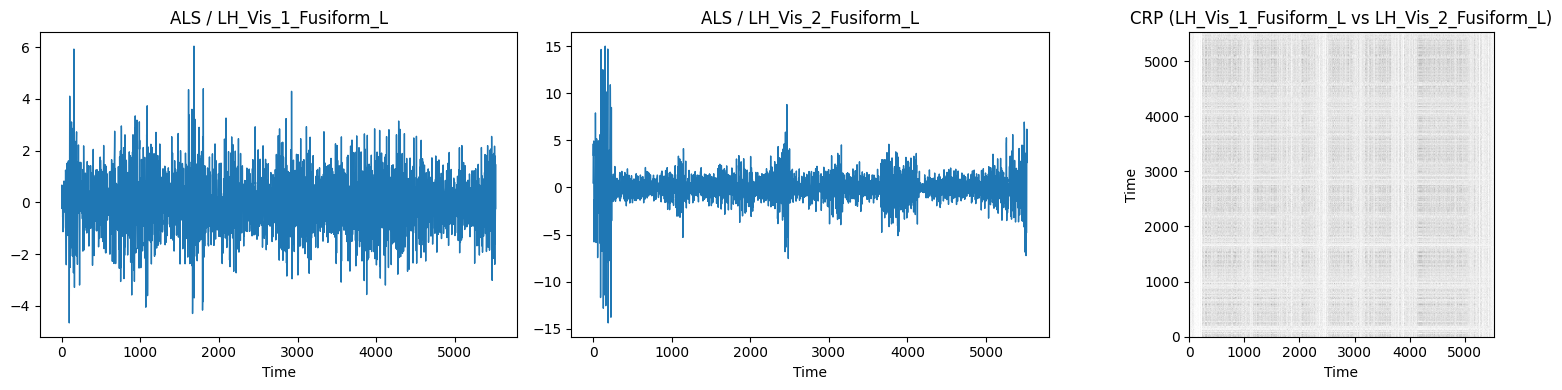

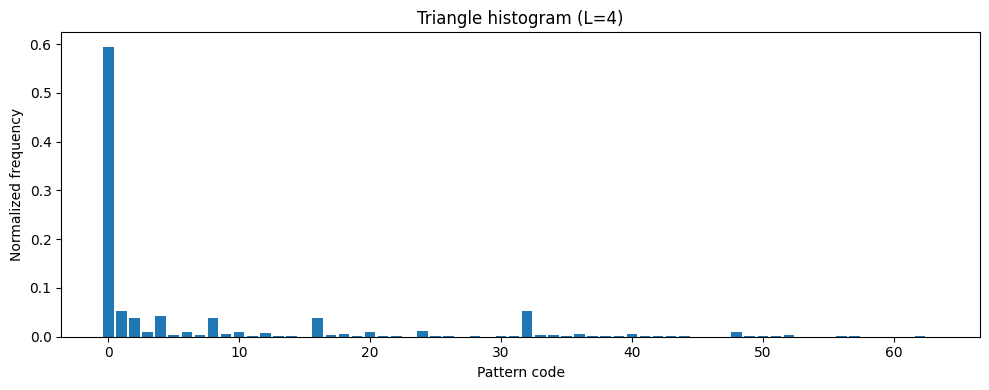

In [ ]:

# =========================================================
# 5) ネスト交差検証 + BayesSearchCV + 線形SVM
# =========================================================

def nested_cv_bayes_linear_svm(
    X, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
):
    """
    線形SVMを BayesSearchCV で最適化し、
    outer CV の精度を評価する。
    """
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    outer_cv = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    oof_pred = np.empty_like(y)
    accs, precs, recs, f1s = [], [], [], []
    cms = []
    best_params_each_fold = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        inner_cv = StratifiedKFold(n_splits=n_splits_inner, shuffle=True, random_state=random_state + fold)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="linear", probability=False, random_state=random_state))
        ])

        search_spaces = {
            "svm__C": Real(1e-3, 1e4, prior="log-uniform"),
            "svm__class_weight": Categorical([None, "balanced"])
        }

        opt = BayesSearchCV(
            estimator=pipe,
            search_spaces=search_spaces,
            n_iter=n_iter,
            cv=inner_cv,
            scoring="accuracy",
            n_jobs=-1,
            random_state=random_state,
            refit=True
        )

        opt.fit(X_tr, y_tr)
        best_model = opt.best_estimator_

        y_pred = best_model.predict(X_te)
        oof_pred[te_idx] = y_pred

        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_te, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_te, y_pred, average="binary", zero_division=0)
        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
        cms.append(cm)
        best_params_each_fold.append(opt.best_params_)

        print(f"\n[Fold {fold}]")
        print("Best params:", opt.best_params_)
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1       : {f1:.4f}")
        print("Confusion matrix:\n", cm)

    cm_sum = np.sum(cms, axis=0)

    print("\n========== Nested CV Result ==========")
    print(f"Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f}")
    print(f"Recall   : {np.mean(recs):.4f}")
    print(f"F1       : {np.mean(f1s):.4f}")

    print("\nOOF classification report:")
    print(classification_report(y, oof_pred, target_names=["HC", "ALS"], zero_division=0))

    return {
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs)),
        "accuracy_by_fold": [float(v) for v in accs],
        "precision_mean": float(np.mean(precs)),
        "recall_mean": float(np.mean(recs)),
        "f1_mean": float(np.mean(f1s)),
        "confusion_sum": cm_sum,
        "oof_pred": oof_pred,
        "best_params_each_fold": best_params_each_fold,
    }


def plot_confusion_matrix(cm, class_names=("HC", "ALS"), title="Confusion Matrix"):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================================================
# 6) 実行
# =========================================================

# fmri_data がすでに作成済みであることを前提
subject_ids, X_subjects, y, signal_cols = build_subject_matrices(fmri_data)

print("Number of subjects:", len(subject_ids))
print("Number of channels:", len(signal_cols))
print("Example shape:", X_subjects[0].shape)
print("Class balance (HC=0, ALS=1):", np.bincount(y))


# ---- 任意: サンプルの CRP 可視化 ----
plot_sample_crp_and_hist(
    X_subjects, y, subject_ids, signal_cols,
    subject_index=0, ch_i=0, ch_j=1, L=4, percentage=0.1
)


# ---- 特徴量作成 ----
# 注意:
# 156チャネルならペア数は 156*155/2 = 12090
# 157チャネルならペア数は 157*156/2 = 12246
# 計算がかなり重いので n_jobs を適宜調整してください
X_feat = build_feature_matrix(
    X_subjects,
    L=4,
    percentage=0.1,
    normalize_each_pair=False,
    n_jobs=2   # Colab のCPUに応じて 1,2,4 など調整
)

print("Feature matrix shape:", X_feat.shape)   # (n_subjects, 64)


# ---- 分類 ----
result = nested_cv_bayes_linear_svm(
    X_feat, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
)

plot_confusion_matrix(result["confusion_sum"], class_names=("HC", "ALS"),
                      title="Linear SVM (Triangle histogram aggregated over all CRPs)")
